# Fixation Regional PC CCA and Connectivity-Constrained mRNNs

This notebook builds 42-PC regional fixation trajectories, checks pairwise CCA across regions, and compares three mRNN recurrent-connectivity variants:

- `full`: all region-to-region recurrent blocks.
- `within_region`: only each region's internal recurrent block.
- `cross_region_with_self_diagonal`: cross-region recurrent blocks plus diagonal self dynamics inside each region.

The model settings here use 50 hidden units per region, `tanh` activation, and unconstrained recurrent/input weights.

## 1. Setup

In [1]:
from pathlib import Path
from dataclasses import replace
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())

import sys
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from dal_monte_2022_analysis.ephys.modeling import (
    backproject_replay_outputs_to_firing_rates,
    compute_pairwise_regional_pc_cca,
    load_fixation_mrnn_config,
    make_targets,
    pc_reconstructed_firing_rate_accuracy,
    plot_pairwise_cca_variance,
    reconstruction_accuracy,
    replay_fixation_mrnn_run,
    settings_from_config,
    train_fixation_mrnn_scratch,
    variance_comparison,
)
from dal_monte_2022_analysis.ephys.plotting.fixation_mrnn import (
    plot_fixation_mrnn_activation_pc_timeseries,
)


def display_figure(fig, *, dpi=150):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


## 2. Fixed Model and Target Settings

In [2]:
cfg = load_fixation_mrnn_config(repo_root / "configs" / "ephys_fixation_mrnn.yaml")
base_settings = settings_from_config(cfg)
base_settings.dataset_cfg_path = str(repo_root / "configs" / "dataset.yaml")
base_settings.device = "auto"
base_settings.target_mode = "region_pcs"
base_settings.pca_n_components = 42
base_settings.temporal_basis_count = 0
base_settings.hidden_units = 40
base_settings.activation = "tanh"
base_settings.rec_constrained = False
base_settings.inp_constrained = False
base_settings.spectral_radius = 1.1
base_settings.epochs = 50_000
base_settings.lr = 3e-4
base_settings.loss_fn = "mse"
base_settings.temporal_derivative_loss_scale = 1.0
base_settings.temporal_curvature_loss_scale = 0.5
base_settings.correlation_loss_scale = 0.0
base_settings.variance_loss_scale = 0.0
base_settings.fr_reconstruction_loss_scale = 0.0
base_settings.fr_temporal_derivative_loss_scale = 0.0
base_settings.fr_temporal_curvature_loss_scale = 0.0
base_settings.l1_weight_scale = 0.0
base_settings.l1_rate_scale = 0.0
base_settings.l2_weight_scale = 0.0
base_settings.l2_rate_scale = 0.0
base_settings.gradient_clip_norm = 1.0
base_settings.initialization_mode = "single"
base_settings.overwrite_seed_plan = False
base_settings

FixationMRNNRunSettings(dataset_cfg_path='/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/configs/dataset.yaml', input_subdir='ephys/psth/fixation_psth_averages', dataframe_filename='fixations_psth_10ms_combined_window_neg500ms_to_pos500ms.pkl', timeline_filename='fixations_psth_10ms_bin_centers_s_rel_window_neg500ms_to_pos500ms.pkl', output_subdir='ephys/modeling/fixation_mrnn', region_order=('ofc', 'bla', 'dmpfc', 'accg'), condition_order=('face_interactive', 'face_non_interactive', 'object'), target_mode='region_pcs', normalize_targets=True, normalization_stabilizer=5.0, pca_variance_threshold=0.95, pca_n_components=42, temporal_basis_count=0, hidden_units=40, activation='tanh', spectral_radius=1.1, rec_constrained=False, inp_constrained=False, recurrent_connectivity='full', batch_first=True, inp_noise=0.0, act_noise=0.0, epochs=50000, lr=0.0003, loss_fn='mse', temporal_derivative_loss_scale=1.0, temporal_curvature_loss_scale=0.5, correlation_loss_scale=0.0, varian

## 3. Build 42-PC Regional Targets

In [3]:
targets = make_targets(base_settings)
rows = []
for region in targets.region_order:
    pca = targets.pca_by_region[region]
    rows.append({
        "region": region,
        "raw_shape": targets.raw_by_region[region].shape,
        "pc_shape": targets.pcs_by_region[region].shape,
        "n_source_neurons": len(pca.source_features),
        "saved_pc_components": targets.pcs_by_region[region].shape[-1],
        "pcs_required_by_variance_rule": pca.n_components_required,
        "normalization_scale": targets.normalization_scale,
    })
display(pd.DataFrame(rows))

,region,raw_shape,pc_shape,n_source_neurons,saved_pc_components,pcs_required_by_variance_rule,normalization_scale
0,ofc,"(3, 100, 241)","(3, 100, 42)",241,42,38,24.363274
1,bla,"(3, 100, 537)","(3, 100, 42)",537,42,42,24.363274
2,dmpfc,"(3, 100, 187)","(3, 100, 42)",187,42,33,24.363274
3,accg,"(3, 100, 236)","(3, 100, 42)",236,42,40,24.363274


## 4. Pairwise Regional CCA

### How CCA Is Applied Here

For a pair of regions, let

$$X \in \mathbb{R}^{n \times p}$$

be the PC trajectory matrix for region A and

$$Y \in \mathbb{R}^{n \times q}$$

be the PC trajectory matrix for region B. The columns are PC dimensions, not time points. The rows are observations. In the pooled analysis, each row is one condition-time bin, so $n = n_{conditions} \times n_{time}$. In the fixation-type-specific analysis, each row is one time bin within one fixation type, so $n = n_{time}$.

CCA finds vectors $a_k$ and $b_k$ such that the projected scalar trajectories

$$u_k = X a_k, \qquad v_k = Y b_k$$

have maximal correlation:

$$\rho_k = \max_{a,b} \frac{a^T \Sigma_{XY} b}{\sqrt{a^T \Sigma_{XX} a}\sqrt{b^T \Sigma_{YY} b}}.$$

After each dimension is found, later dimensions are constrained to be uncorrelated with earlier canonical variables. Numerically, the code whitens each regional PC covariance and takes an SVD of the whitened cross-covariance,

$$\Sigma_{XX}^{-1/2}\Sigma_{XY}\Sigma_{YY}^{-1/2} = U S V^T,$$

where the singular values $S$ are the canonical correlations.

Interpretation: high canonical correlation means a linear combination of PCs in one region has a matching linear combination in another region across the chosen observations. The variance-explained curves ask how much of each region's PC-space variance is captured by these canonical variables.

The pooled analysis is useful as a single summary of shared regional dynamics across all fixation types, but it assumes condition-time bins are exchangeable samples from one joint distribution. It does not test whether the same relationship holds within each fixation type. The fixation-type-specific CCA below is the stricter check for condition-dependent shared dynamics. If the pooled CCA is high but condition-specific CCA differs strongly, the pooled result may be driven by condition offsets or between-condition structure rather than within-condition temporal dynamics.

,fixation_type,region_a,region_b,cca_dimension,canonical_correlation,region_a_variance_explained,region_b_variance_explained,mean_variance_explained,region_a_cumulative_variance_explained,region_b_cumulative_variance_explained,mean_cumulative_variance_explained
0,pooled,ofc,bla,1,0.999819,0.285350,0.275681,0.280516,0.285350,0.275681,0.280516
1,pooled,ofc,bla,2,0.999527,0.167460,0.173876,0.170668,0.452811,0.449557,0.451184
2,pooled,ofc,bla,3,0.998971,0.049034,0.029504,0.039269,0.501845,0.479061,0.490453
3,pooled,ofc,bla,4,0.998421,0.024455,0.028835,0.026645,0.526300,0.507897,0.517098
4,pooled,ofc,bla,5,0.998216,0.032083,0.019843,0.025963,0.558383,0.527740,0.543061
5,pooled,ofc,bla,6,0.997673,0.020491,0.017074,0.018782,0.578874,0.544814,0.561844
6,pooled,ofc,bla,7,0.997563,0.025367,0.022299,0.023833,0.604241,0.567113,0.585677
7,pooled,ofc,bla,8,0.996484,0.016726,0.016250,0.016488,0.620967,0.583362,0.602164
8,pooled,ofc,bla,9,0.995962,0.013904,0.018611,0.016257,0.634870,0.601974,0.618422
9,pooled,ofc,bla,10,0.995155,0.013549,0.012633,0.013091,0.648419,0.614607,0.631513


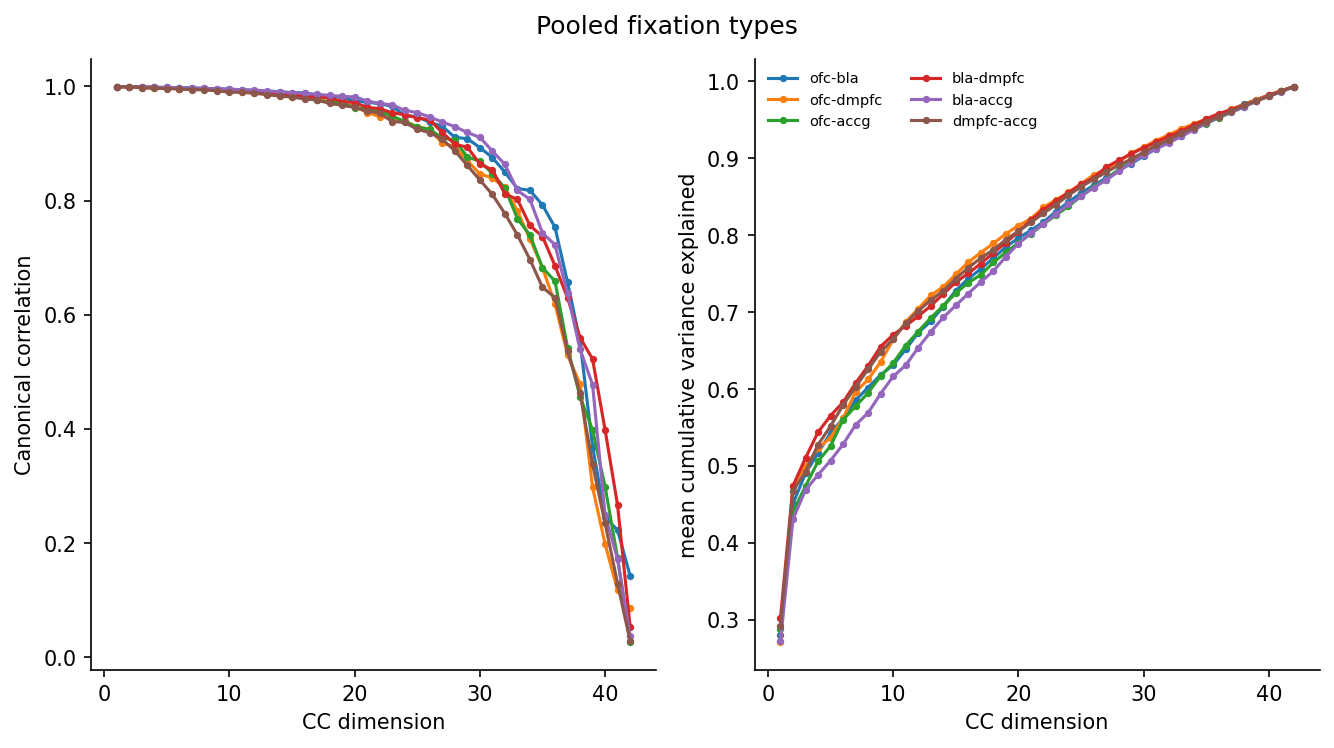

In [4]:
pooled_cca_df, pooled_cca_payloads = compute_pairwise_regional_pc_cca(
    targets.pcs_by_region,
    region_order=targets.region_order,
    max_components=42,
)
pooled_cca_df.insert(0, "fixation_type", "pooled")
display(pooled_cca_df.head(12))
fig, axes = plot_pairwise_cca_variance(pooled_cca_df, max_dimensions=42)
fig.suptitle("Pooled fixation types", y=1.03)
display_figure(fig)

cca_df = pooled_cca_df
cca_payloads = pooled_cca_payloads

In [5]:
summary_cols = [
    "fixation_type",
    "region_a",
    "region_b",
    "cca_dimension",
    "canonical_correlation",
    "mean_cumulative_variance_explained",
]
display(
    cca_df.loc[cca_df["cca_dimension"].isin([1, 5, 10, 20, 42]), summary_cols]
    .sort_values(["fixation_type", "region_a", "region_b", "cca_dimension"])
    .reset_index(drop=True)
)

,fixation_type,region_a,region_b,cca_dimension,canonical_correlation,mean_cumulative_variance_explained
0,pooled,bla,accg,1,0.999697,0.272574
1,pooled,bla,accg,5,0.998134,0.507207
2,pooled,bla,accg,10,0.994860,0.616584
3,pooled,bla,accg,20,0.981668,0.789227
4,pooled,bla,accg,42,0.036775,0.993424
5,pooled,bla,dmpfc,1,0.999703,0.302022
6,pooled,bla,dmpfc,5,0.997419,0.565570
7,pooled,bla,dmpfc,10,0.992481,0.670747
8,pooled,bla,dmpfc,20,0.971536,0.804550
9,pooled,bla,dmpfc,42,0.053770,0.993420


## 4b. Fixation-Type-Specific Regional CCA

The pooled CCA above concatenates all three fixation types across the observation axis. This section repeats the same region-pair CCA separately for each fixation type, using time bins as observations within that condition.

,fixation_type,region_a,region_b,cca_dimension,canonical_correlation,region_a_variance_explained,region_b_variance_explained,mean_variance_explained,region_a_cumulative_variance_explained,region_b_cumulative_variance_explained,mean_cumulative_variance_explained
0,face_interactive,ofc,bla,1,0.999957,0.357134,0.419423,0.388279,0.357134,0.419423,0.388279
1,face_interactive,ofc,bla,2,0.999859,0.152950,0.113739,0.133344,0.510084,0.533162,0.521623
2,face_interactive,ofc,bla,3,0.999831,0.076653,0.089655,0.083154,0.586738,0.622817,0.604777
3,face_interactive,ofc,bla,4,0.999749,0.081505,0.107542,0.094524,0.668243,0.730360,0.699301
4,face_interactive,ofc,bla,5,0.999650,0.057849,0.060132,0.058991,0.726092,0.790492,0.758292
5,face_interactive,ofc,bla,6,0.999484,0.055249,0.027949,0.041599,0.781341,0.818441,0.799891
6,face_interactive,ofc,bla,7,0.999208,0.039826,0.032091,0.035959,0.821167,0.850532,0.835850
7,face_interactive,ofc,bla,8,0.998978,0.026489,0.029227,0.027858,0.847656,0.879759,0.863707
8,face_interactive,ofc,bla,9,0.998831,0.022440,0.014368,0.018404,0.870096,0.894127,0.882111
9,face_interactive,ofc,bla,10,0.998601,0.018290,0.011081,0.014685,0.888385,0.905207,0.896796


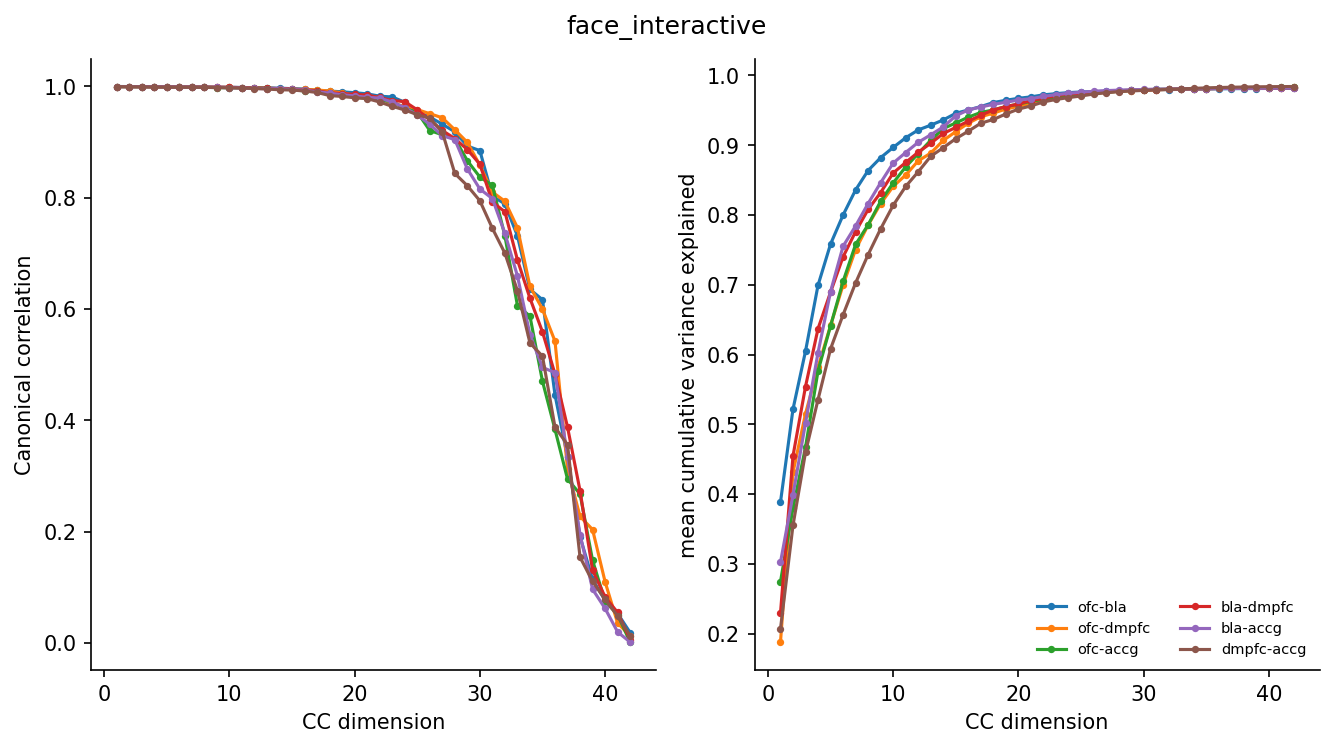

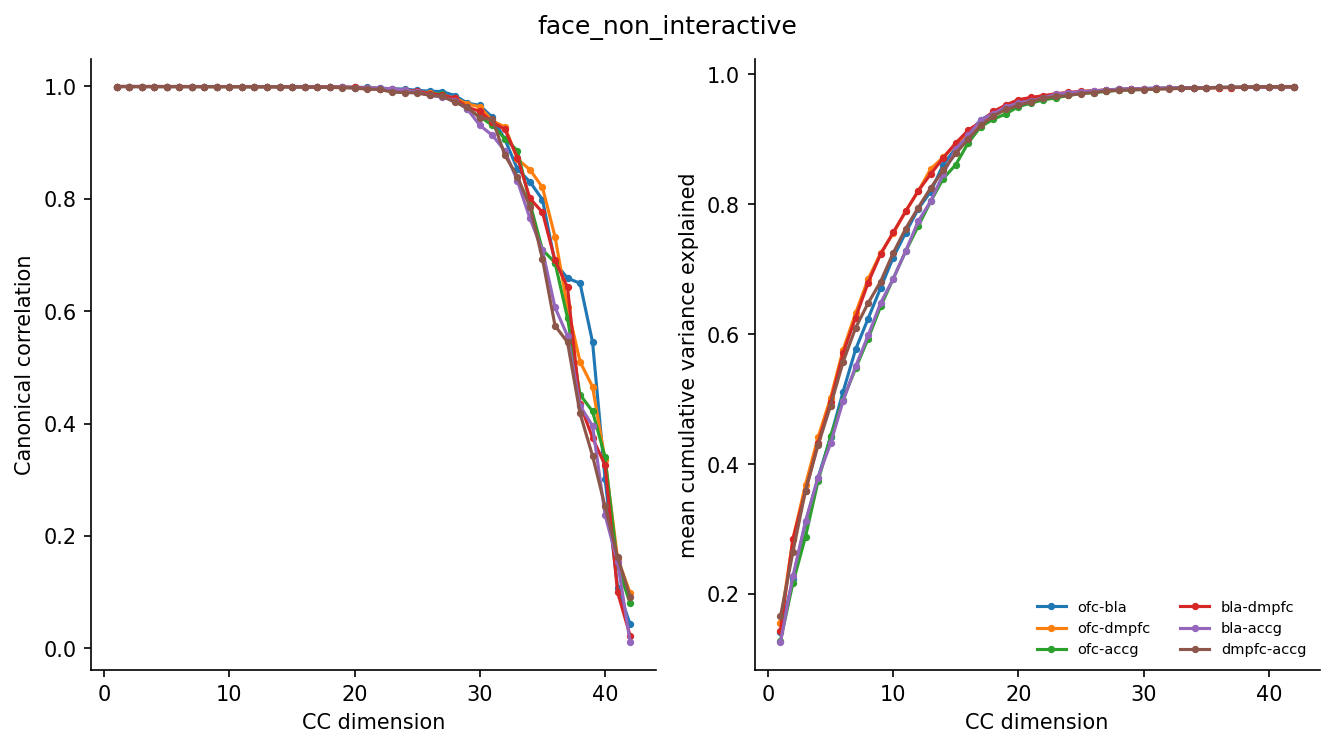

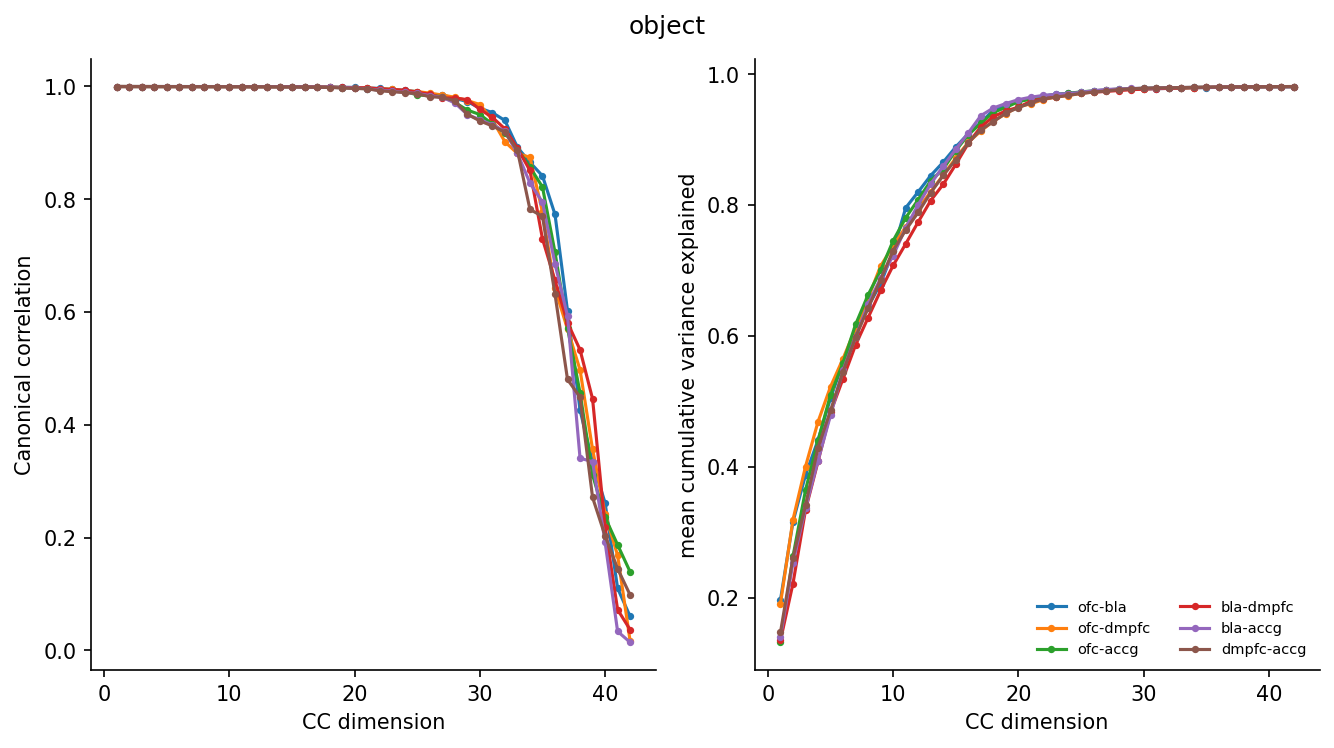

In [6]:
condition_cca_tables = []
condition_cca_payloads = {}
for cond_idx, condition in enumerate(targets.condition_order):
    condition_pcs = {
        region: targets.pcs_by_region[region][cond_idx : cond_idx + 1]
        for region in targets.region_order
    }
    cond_df, cond_payload = compute_pairwise_regional_pc_cca(
        condition_pcs,
        region_order=targets.region_order,
        max_components=42,
    )
    cond_df.insert(0, "fixation_type", condition)
    condition_cca_tables.append(cond_df)
    condition_cca_payloads[condition] = cond_payload

condition_cca_df = pd.concat(condition_cca_tables, ignore_index=True)
display(condition_cca_df.head(12))
for condition, sub in condition_cca_df.groupby("fixation_type", sort=False):
    fig, axes = plot_pairwise_cca_variance(sub, max_dimensions=42)
    fig.suptitle(condition, y=1.03)
    display_figure(fig)

all_cca_df = pd.concat([pooled_cca_df, condition_cca_df], ignore_index=True)


In [7]:
display(
    all_cca_df.loc[all_cca_df["cca_dimension"].isin([1, 5, 10, 20, 42]), summary_cols]
    .sort_values(["fixation_type", "region_a", "region_b", "cca_dimension"])
    .reset_index(drop=True)
)

,fixation_type,region_a,region_b,cca_dimension,canonical_correlation,mean_cumulative_variance_explained
0,face_interactive,bla,accg,1,0.999783,0.302078
1,face_interactive,bla,accg,5,0.999365,0.690197
2,face_interactive,bla,accg,10,0.997625,0.874320
3,face_interactive,bla,accg,20,0.983032,0.964670
4,face_interactive,bla,accg,42,0.001177,0.981987
...,...,...,...,...,...,...
115,pooled,ofc,dmpfc,1,0.999522,0.270933
116,pooled,ofc,dmpfc,5,0.996615,0.537148
117,pooled,ofc,dmpfc,10,0.992892,0.664652
118,pooled,ofc,dmpfc,20,0.965239,0.812577


## 5. Train or Load the Three Connectivity Models

In [8]:
connectivity_variants = {
    "full": "full",
    "within_region": "within_region",
    "cross_region_with_self_diagonal": "cross_region_with_self_diagonal",
}
run_mode = "train"  # use "train" to refit; use "load" to read existing scratch runs
overwrite = True


def load_or_train_connectivity_model(label, connectivity):
    settings = replace(base_settings, recurrent_connectivity=connectivity)
    scratch_id = f"cca_42pc_tanh_h40_{label}"
    run_root = Path(settings.output_subdir)
    if run_mode == "train":
        result = train_fixation_mrnn_scratch(settings, scratch_id=scratch_id, overwrite=overwrite)
        replay = replay_fixation_mrnn_run(result["run_dir"], device=settings.device)
        return {"label": label, "settings": settings, "result": result, "replay": replay}

    from dal_monte_2022_analysis.ephys.modeling import resolve_fixation_mrnn_output_root
    run_dir = resolve_fixation_mrnn_output_root(settings) / "scratch" / scratch_id
    checkpoint = run_dir / "checkpoint_final.pth"
    if not checkpoint.exists():
        print(f"Missing checkpoint for {label}: {checkpoint}")
        return {"label": label, "settings": settings, "result": None, "replay": None}
    replay = replay_fixation_mrnn_run(run_dir, device=settings.device)
    history = pd.read_csv(run_dir / "history.csv")
    return {"label": label, "settings": settings, "result": {"run_dir": run_dir, "history": history}, "replay": replay}

fits = [
    load_or_train_connectivity_model(label, connectivity)
    for label, connectivity in connectivity_variants.items()
]
[(fit["label"], None if fit["replay"] is None else str(fit["result"]["run_dir"])) for fit in fits]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

region_pcs seed=211382628:   0%|          | 0/50000 [00:00<?, ?iter/s]

[('full',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h40_full'),
 ('within_region',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h40_within_region'),
 ('cross_region_with_self_diagonal',
  '/gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/scratch/cca_42pc_tanh_h40_cross_region_with_self_diagonal')]

## 6. Loss Curves

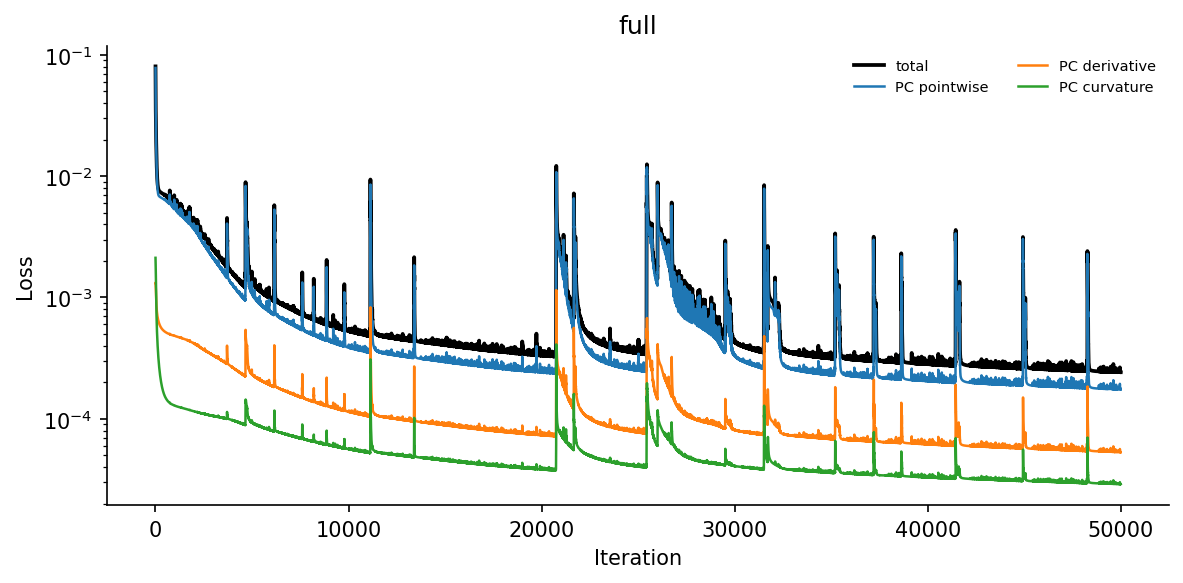

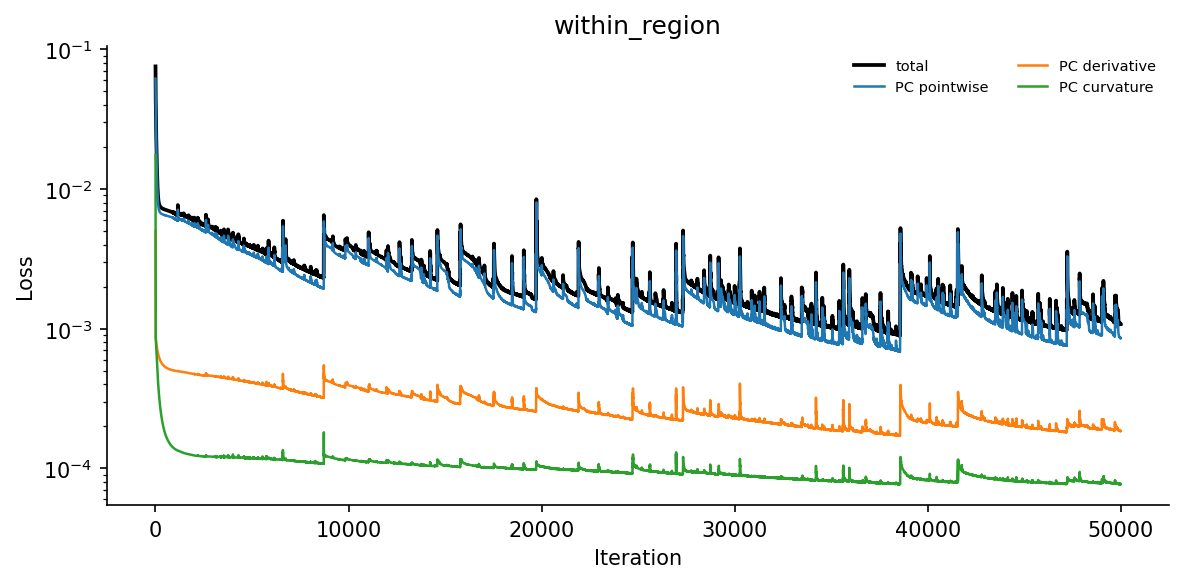

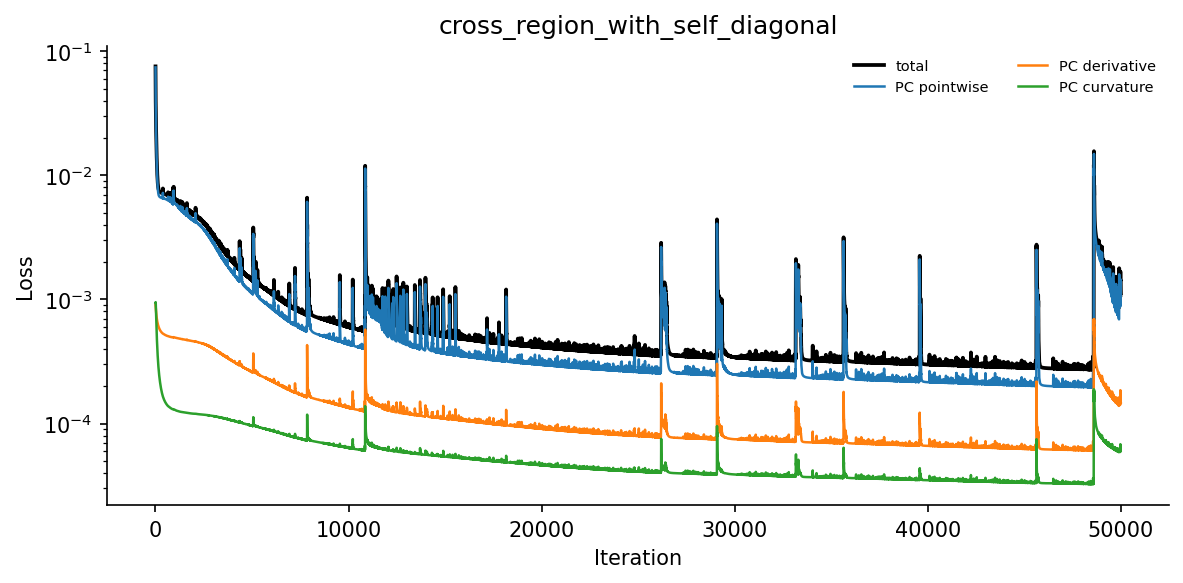

In [9]:
LOSS_COMPONENTS = [
    ("reconstruction_loss", "PC pointwise", 1.0),
    ("temporal_derivative_loss", "PC derivative", "temporal_derivative_loss_scale"),
    ("temporal_curvature_loss", "PC curvature", "temporal_curvature_loss_scale"),
    ("correlation_loss", "PC correlation", "correlation_loss_scale"),
    ("variance_loss", "PC variance", "variance_loss_scale"),
    ("fr_reconstruction_loss", "FR pointwise", "fr_reconstruction_loss_scale"),
    ("fr_temporal_derivative_loss", "FR derivative", "fr_temporal_derivative_loss_scale"),
    ("fr_temporal_curvature_loss", "FR curvature", "fr_temporal_curvature_loss_scale"),
    ("rate_loss", "L1 rate", "l1_rate_scale"),
    ("weight_loss", "L1 weight", "l1_weight_scale"),
    ("l2_rate_loss", "L2 rate", "l2_rate_scale"),
    ("l2_weight_loss", "L2 weight", "l2_weight_scale"),
]


def _loss_weight(settings, weight_spec):
    if isinstance(weight_spec, str):
        return float(getattr(settings, weight_spec, 0.0))
    return float(weight_spec)


def plot_loss(history, title, *, settings):
    fig, ax = plt.subplots(figsize=(8.0, 4.0), dpi=130)
    if "loss" in history:
        ax.plot(history["iteration"], history["loss"], label="total", linewidth=1.8, color="black")
    plotted = 1
    for column, label, weight_spec in LOSS_COMPONENTS:
        if column not in history:
            continue
        if _loss_weight(settings, weight_spec) == 0.0:
            continue
        ax.plot(history["iteration"], history[column], label=label, linewidth=1.2)
        plotted += 1
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    if plotted > 1:
        ax.legend(frameon=False, fontsize=7, ncol=2)
    fig.tight_layout()
    return fig, ax

for fit in fits:
    if fit["result"] is None:
        continue
    history = fit["result"]["history"]
    fig, axes = plot_loss(history, fit["label"], settings=fit["settings"])
    display_figure(fig)


## 7. PC Reconstruction Quality

In [10]:
pc_metric_tables = []
for fit in fits:
    if fit["replay"] is None:
        continue
    metrics = reconstruction_accuracy(fit["replay"])
    metrics.insert(0, "model", fit["label"])
    pc_metric_tables.append(metrics)

pc_metrics = pd.concat(pc_metric_tables, ignore_index=True) if pc_metric_tables else pd.DataFrame()
display(pc_metrics)
if not pc_metrics.empty:
    display(
        pc_metrics.groupby(["model", "region"], sort=False)[["r2", "correlation", "mse", "mae"]]
        .mean(numeric_only=True)
        .reset_index()
    )

,model,region,condition,mse,mae,r2,correlation
0,full,ofc,face_interactive,0.000290,0.012778,0.966370,0.983042
1,full,ofc,face_non_interactive,0.000107,0.007675,0.991564,0.995774
2,full,ofc,object,0.000158,0.008724,0.991466,0.995724
3,full,bla,face_interactive,0.000368,0.012867,0.973615,0.986724
4,full,bla,face_non_interactive,0.000211,0.008722,0.992499,0.996242
5,full,bla,object,0.000144,0.007811,0.995068,0.997531
6,full,dmpfc,face_interactive,0.000237,0.011716,0.944293,0.971750
7,full,dmpfc,face_non_interactive,0.000113,0.008060,0.990148,0.995062
8,full,dmpfc,object,0.000100,0.007797,0.988708,0.994339
9,full,accg,face_interactive,0.000190,0.010641,0.925180,0.961878


,model,region,r2,correlation,mse,mae
0,full,ofc,0.983133,0.991513,0.000185,0.009726
1,full,bla,0.987060,0.993499,0.000241,0.009800
2,full,dmpfc,0.974383,0.987050,0.000150,0.009191
3,full,accg,0.966100,0.982799,0.000122,0.008295
4,within_region,ofc,0.939482,0.969196,0.000699,0.020812
5,within_region,bla,0.942529,0.970812,0.001328,0.026843
6,within_region,dmpfc,0.845274,0.917211,0.001183,0.023305
7,within_region,accg,0.940768,0.969513,0.000206,0.011031
8,cross_region_with_self_diagonal,ofc,0.909727,0.953516,0.000972,0.023877
9,cross_region_with_self_diagonal,bla,0.919799,0.958754,0.001551,0.029152


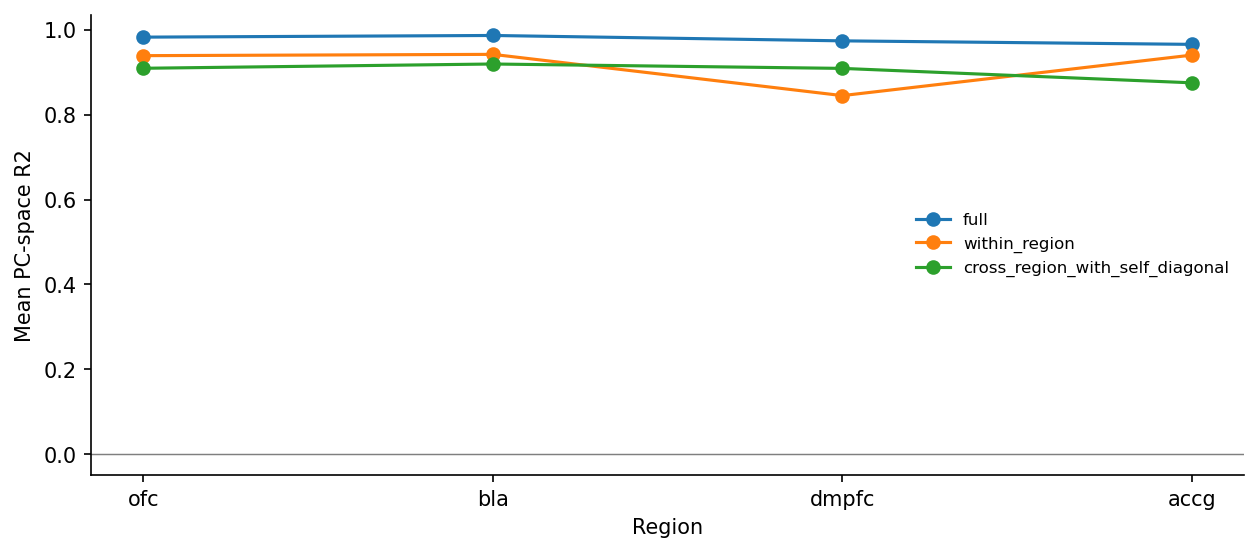

In [11]:
if not pc_metrics.empty:
    fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=130)
    summary = pc_metrics.groupby(["model", "region"], sort=False)["r2"].mean().reset_index()
    for model, sub in summary.groupby("model", sort=False):
        ax.plot(sub["region"], sub["r2"], marker="o", label=model)
    ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel("Mean PC-space R2")
    ax.set_xlabel("Region")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    display_figure(fig)

## 8. Firing-Rate Reconstruction Quality From PC Backprojection

In [12]:
fr_metric_tables = []
variance_tables = []
for fit in fits:
    if fit["replay"] is None:
        continue
    fr_metrics = pc_reconstructed_firing_rate_accuracy(fit["replay"])
    fr_metrics.insert(0, "model", fit["label"])
    fr_metric_tables.append(fr_metrics)
    var_metrics = variance_comparison(fit["replay"])
    var_metrics.insert(0, "model", fit["label"])
    variance_tables.append(var_metrics)

fr_metrics = pd.concat(fr_metric_tables, ignore_index=True) if fr_metric_tables else pd.DataFrame()
variance_metrics = pd.concat(variance_tables, ignore_index=True) if variance_tables else pd.DataFrame()
display(fr_metrics)
if not fr_metrics.empty:
    display(
        fr_metrics.groupby(["model", "region"], sort=False)[["r2", "correlation", "mse", "mae"]]
        .mean(numeric_only=True)
        .reset_index()
    )
display(variance_metrics)

,model,region,condition,mse,mae,r2,correlation
0,full,ofc,face_interactive,0.000051,0.004859,0.999451,0.999725
1,full,ofc,face_non_interactive,0.000019,0.003024,0.999786,0.999893
2,full,ofc,object,0.000028,0.003652,0.999680,0.999840
3,full,bla,face_interactive,0.000029,0.003634,0.999627,0.999813
4,full,bla,face_non_interactive,0.000017,0.002748,0.999774,0.999887
5,full,bla,object,0.000011,0.002290,0.999859,0.999929
6,full,dmpfc,face_interactive,0.000053,0.005111,0.999071,0.999536
7,full,dmpfc,face_non_interactive,0.000025,0.003628,0.999569,0.999784
8,full,dmpfc,object,0.000022,0.003406,0.999584,0.999792
9,full,accg,face_interactive,0.000034,0.004136,0.998974,0.999487


,model,region,r2,correlation,mse,mae
0,full,ofc,0.999639,0.999819,0.000032,0.003845
1,full,bla,0.999753,0.999877,0.000019,0.002891
2,full,dmpfc,0.999408,0.999704,0.000034,0.004048
3,full,accg,0.999324,0.999662,0.000022,0.003273
4,within_region,ofc,0.998624,0.999312,0.000122,0.007468
5,within_region,bla,0.998666,0.999333,0.000104,0.006532
6,within_region,dmpfc,0.995155,0.997572,0.000266,0.009792
7,within_region,accg,0.998865,0.999432,0.000037,0.004070
8,cross_region_with_self_diagonal,ofc,0.998101,0.999051,0.000169,0.008495
9,cross_region_with_self_diagonal,bla,0.998394,0.999199,0.000121,0.006976


,model,region,observed_variance,reconstructed_variance,reconstructed_to_observed_ratio
0,full,ofc,0.013428,0.013227,0.985086
1,full,bla,0.024063,0.023829,0.990258
2,full,dmpfc,0.008286,0.008123,0.980295
3,full,accg,0.005290,0.005162,0.975898
4,within_region,ofc,0.013428,0.012616,0.939563
5,within_region,bla,0.024063,0.022331,0.928009
6,within_region,dmpfc,0.008286,0.007060,0.851967
7,within_region,accg,0.005290,0.005065,0.957560
8,cross_region_with_self_diagonal,ofc,0.013428,0.012432,0.925826
9,cross_region_with_self_diagonal,bla,0.024063,0.022111,0.918884


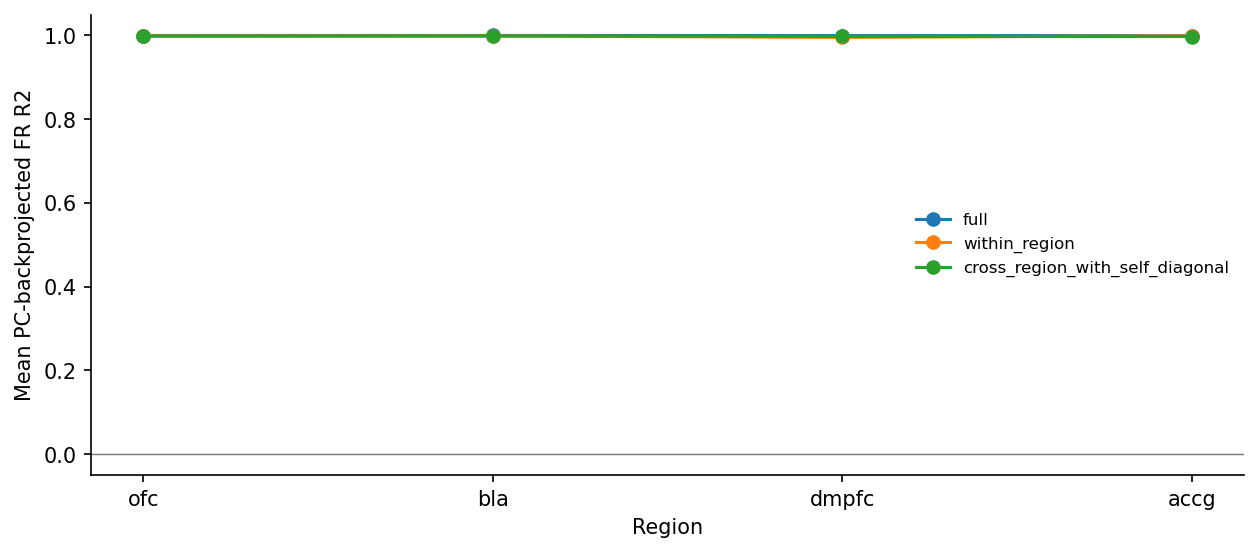

In [13]:
if not fr_metrics.empty:
    fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=130)
    summary = fr_metrics.groupby(["model", "region"], sort=False)["r2"].mean().reset_index()
    for model, sub in summary.groupby("model", sort=False):
        ax.plot(sub["region"], sub["r2"], marker="o", label=model)
    ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    ax.set_ylabel("Mean PC-backprojected FR R2")
    ax.set_xlabel("Region")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    display_figure(fig)

## 9. Visual Reconstruction Overlays


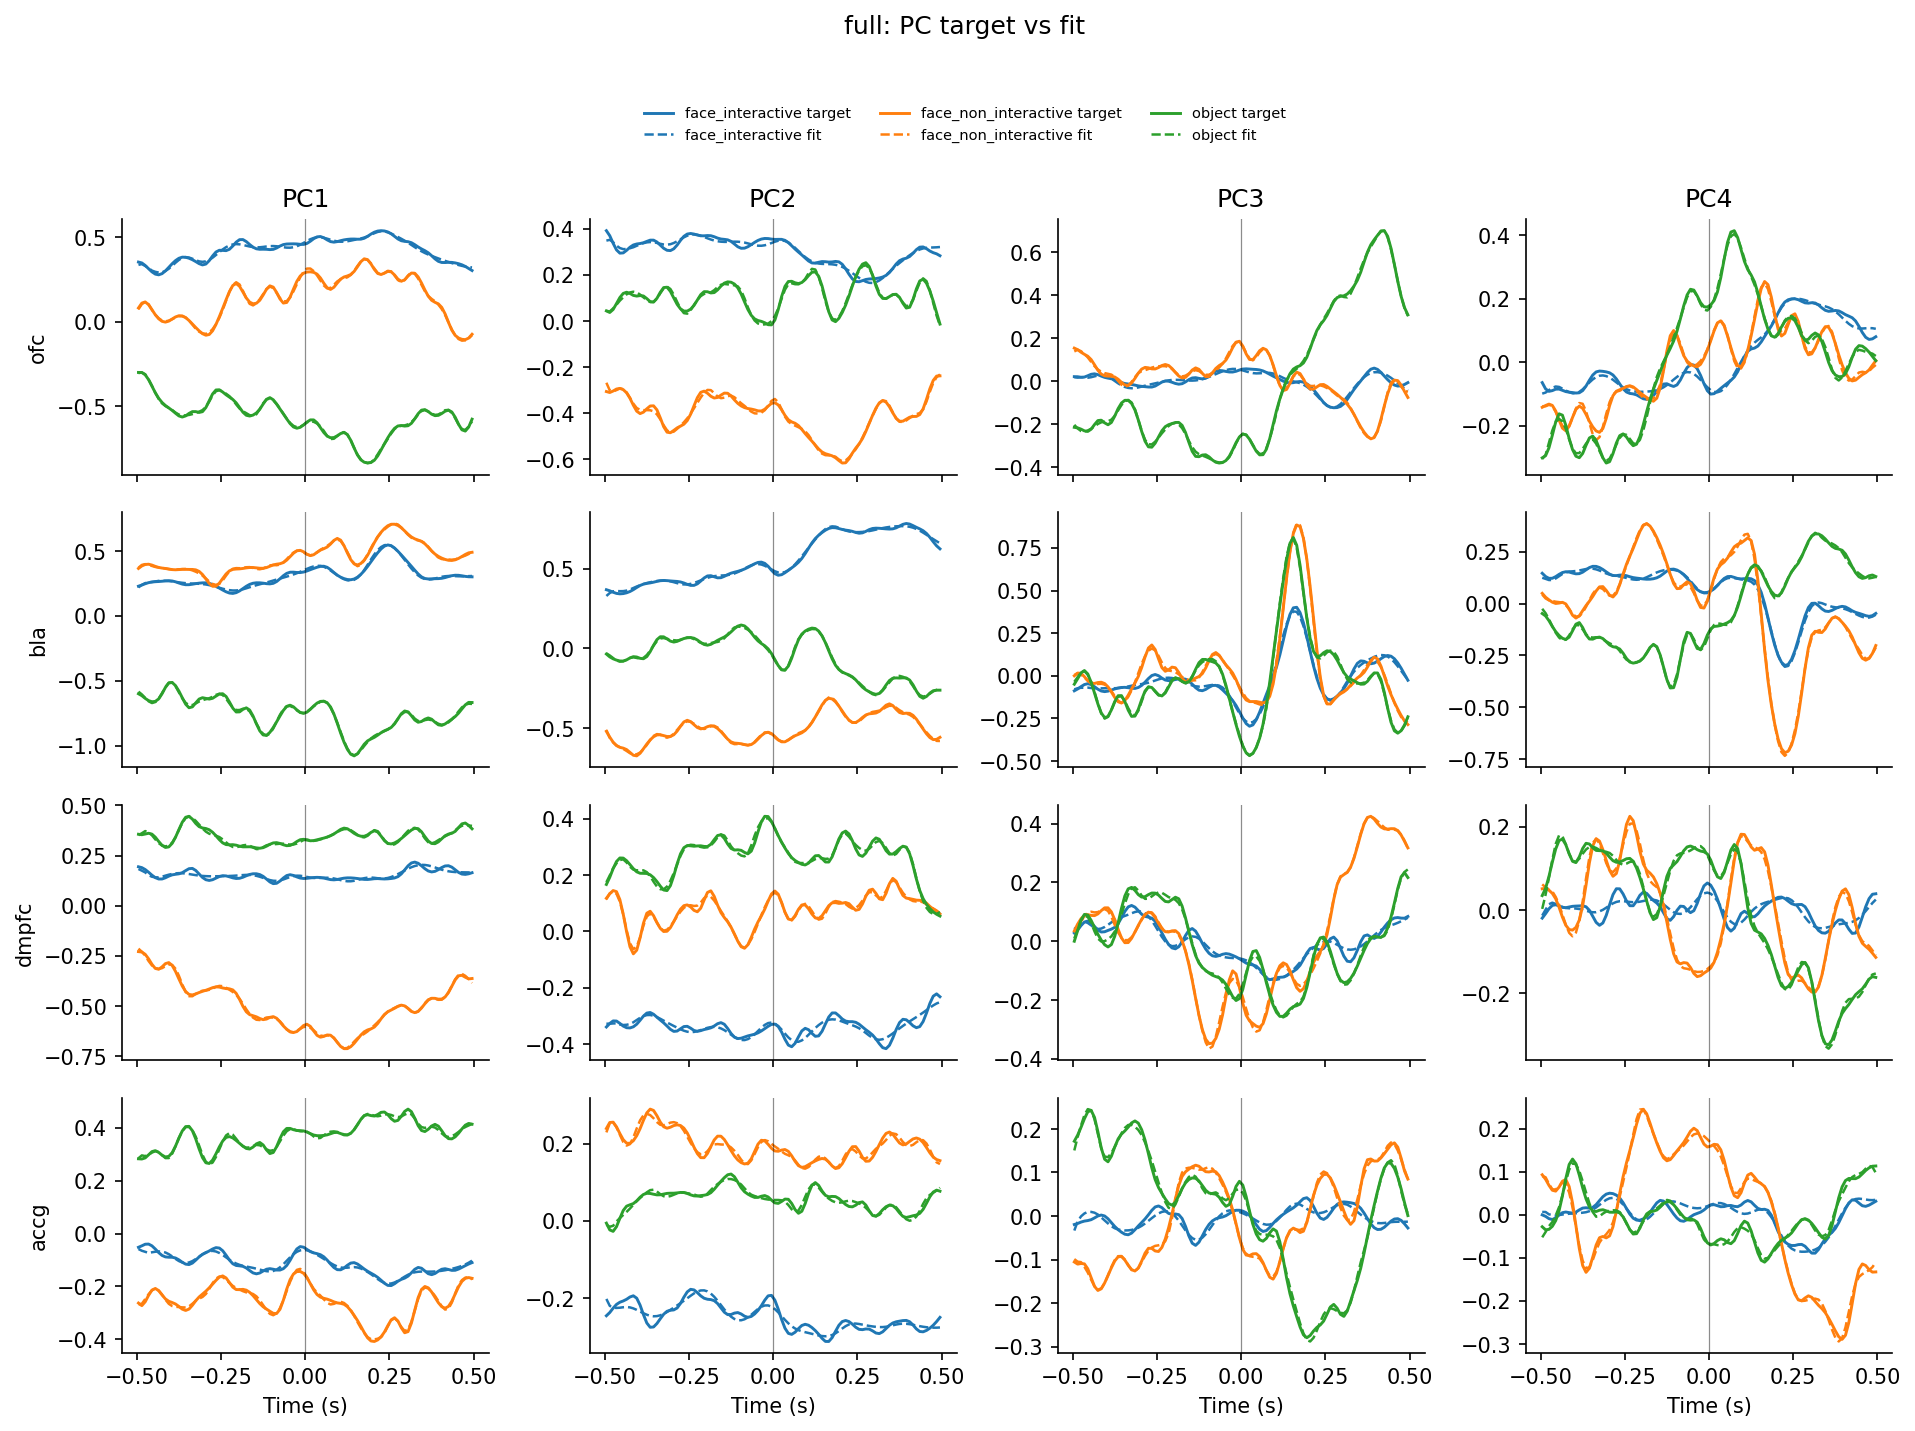

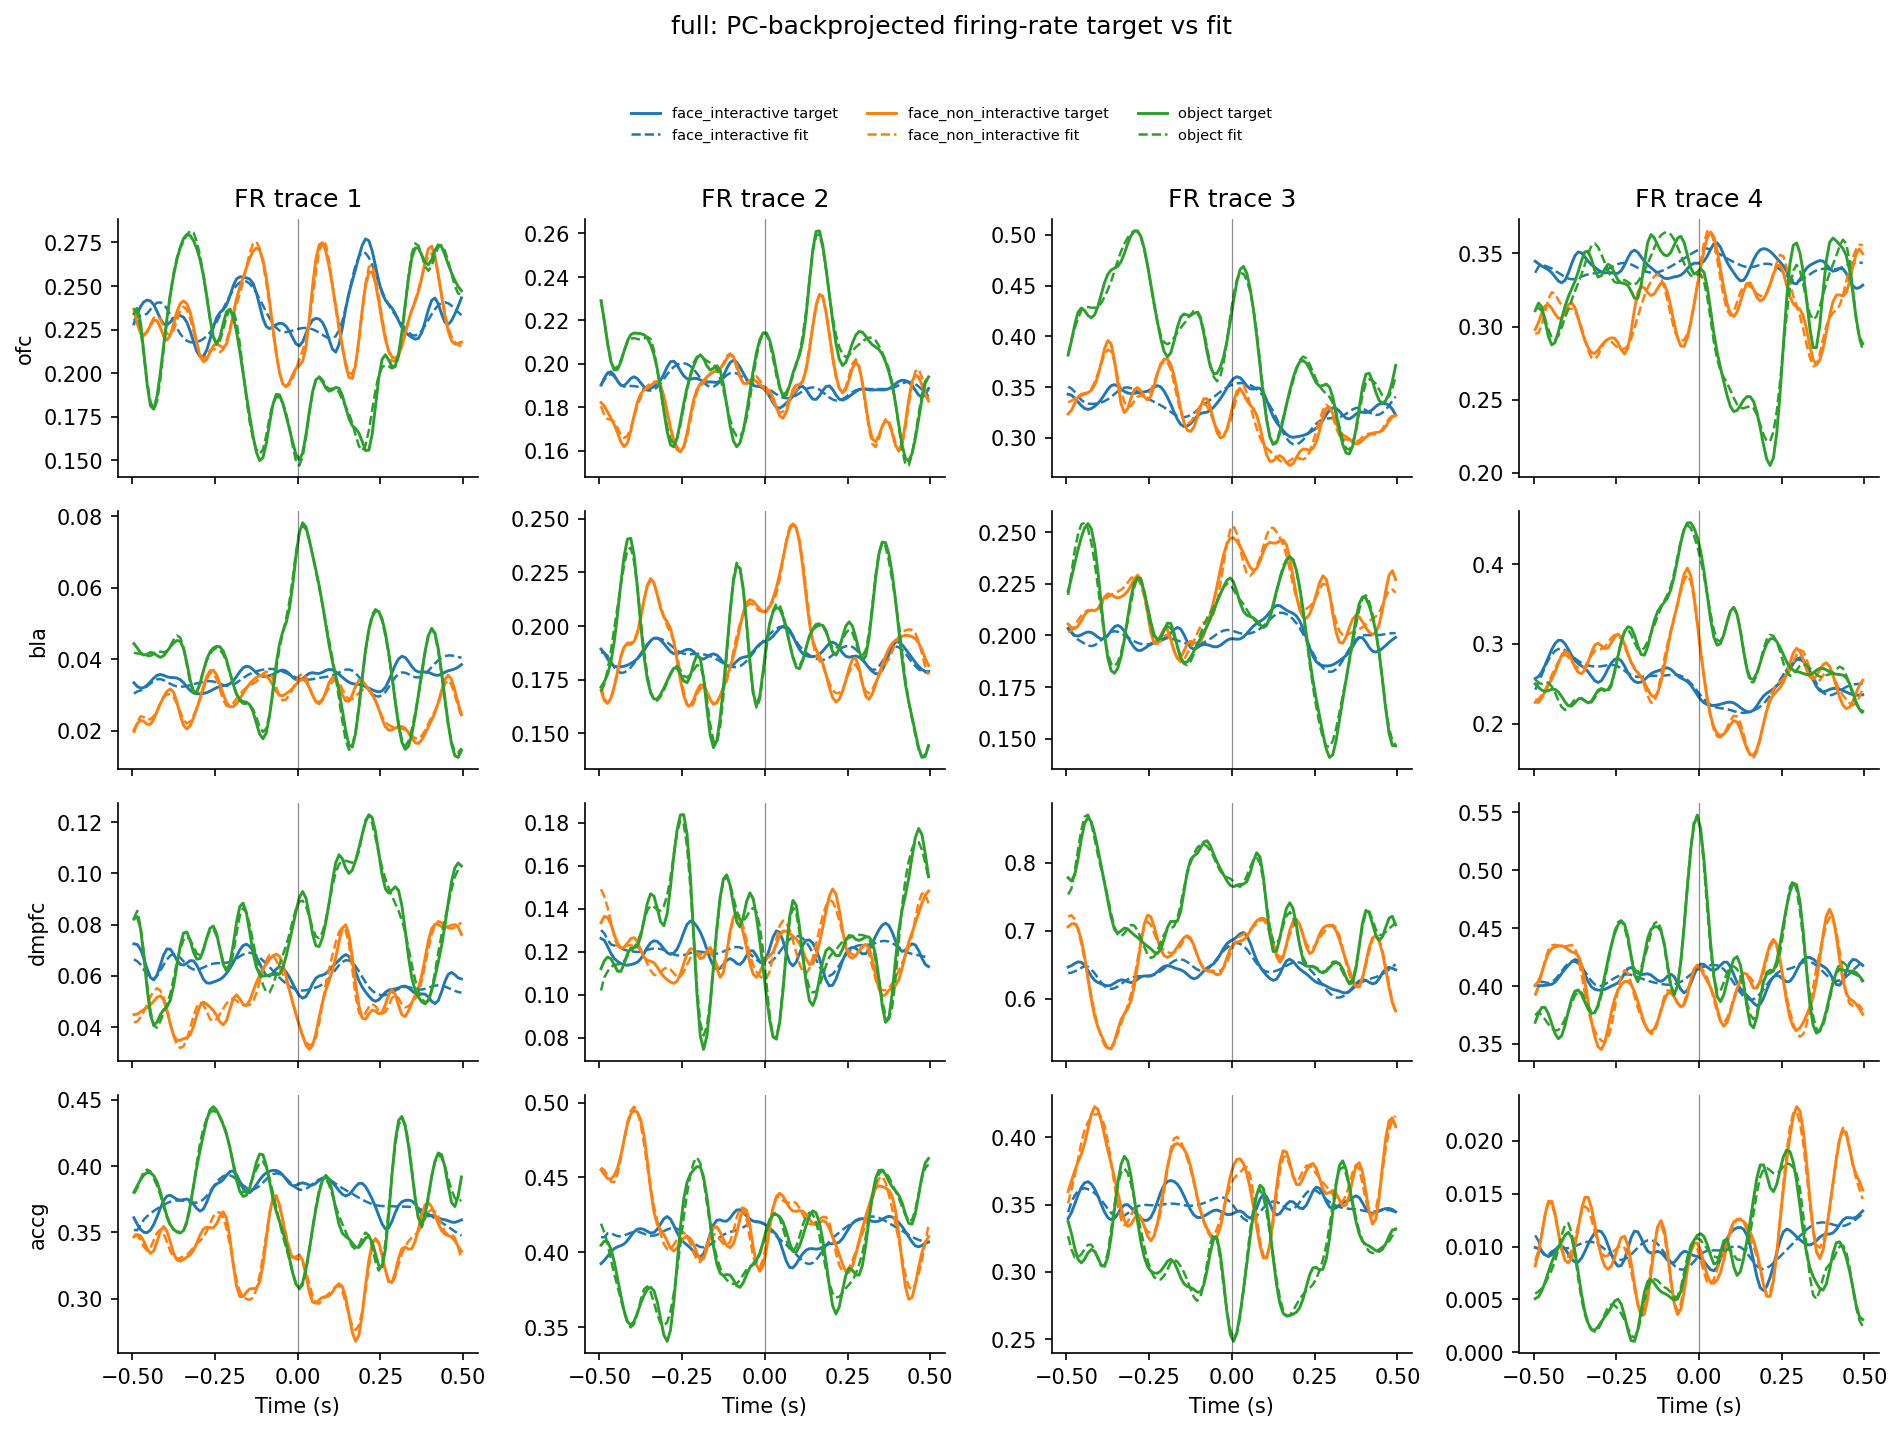

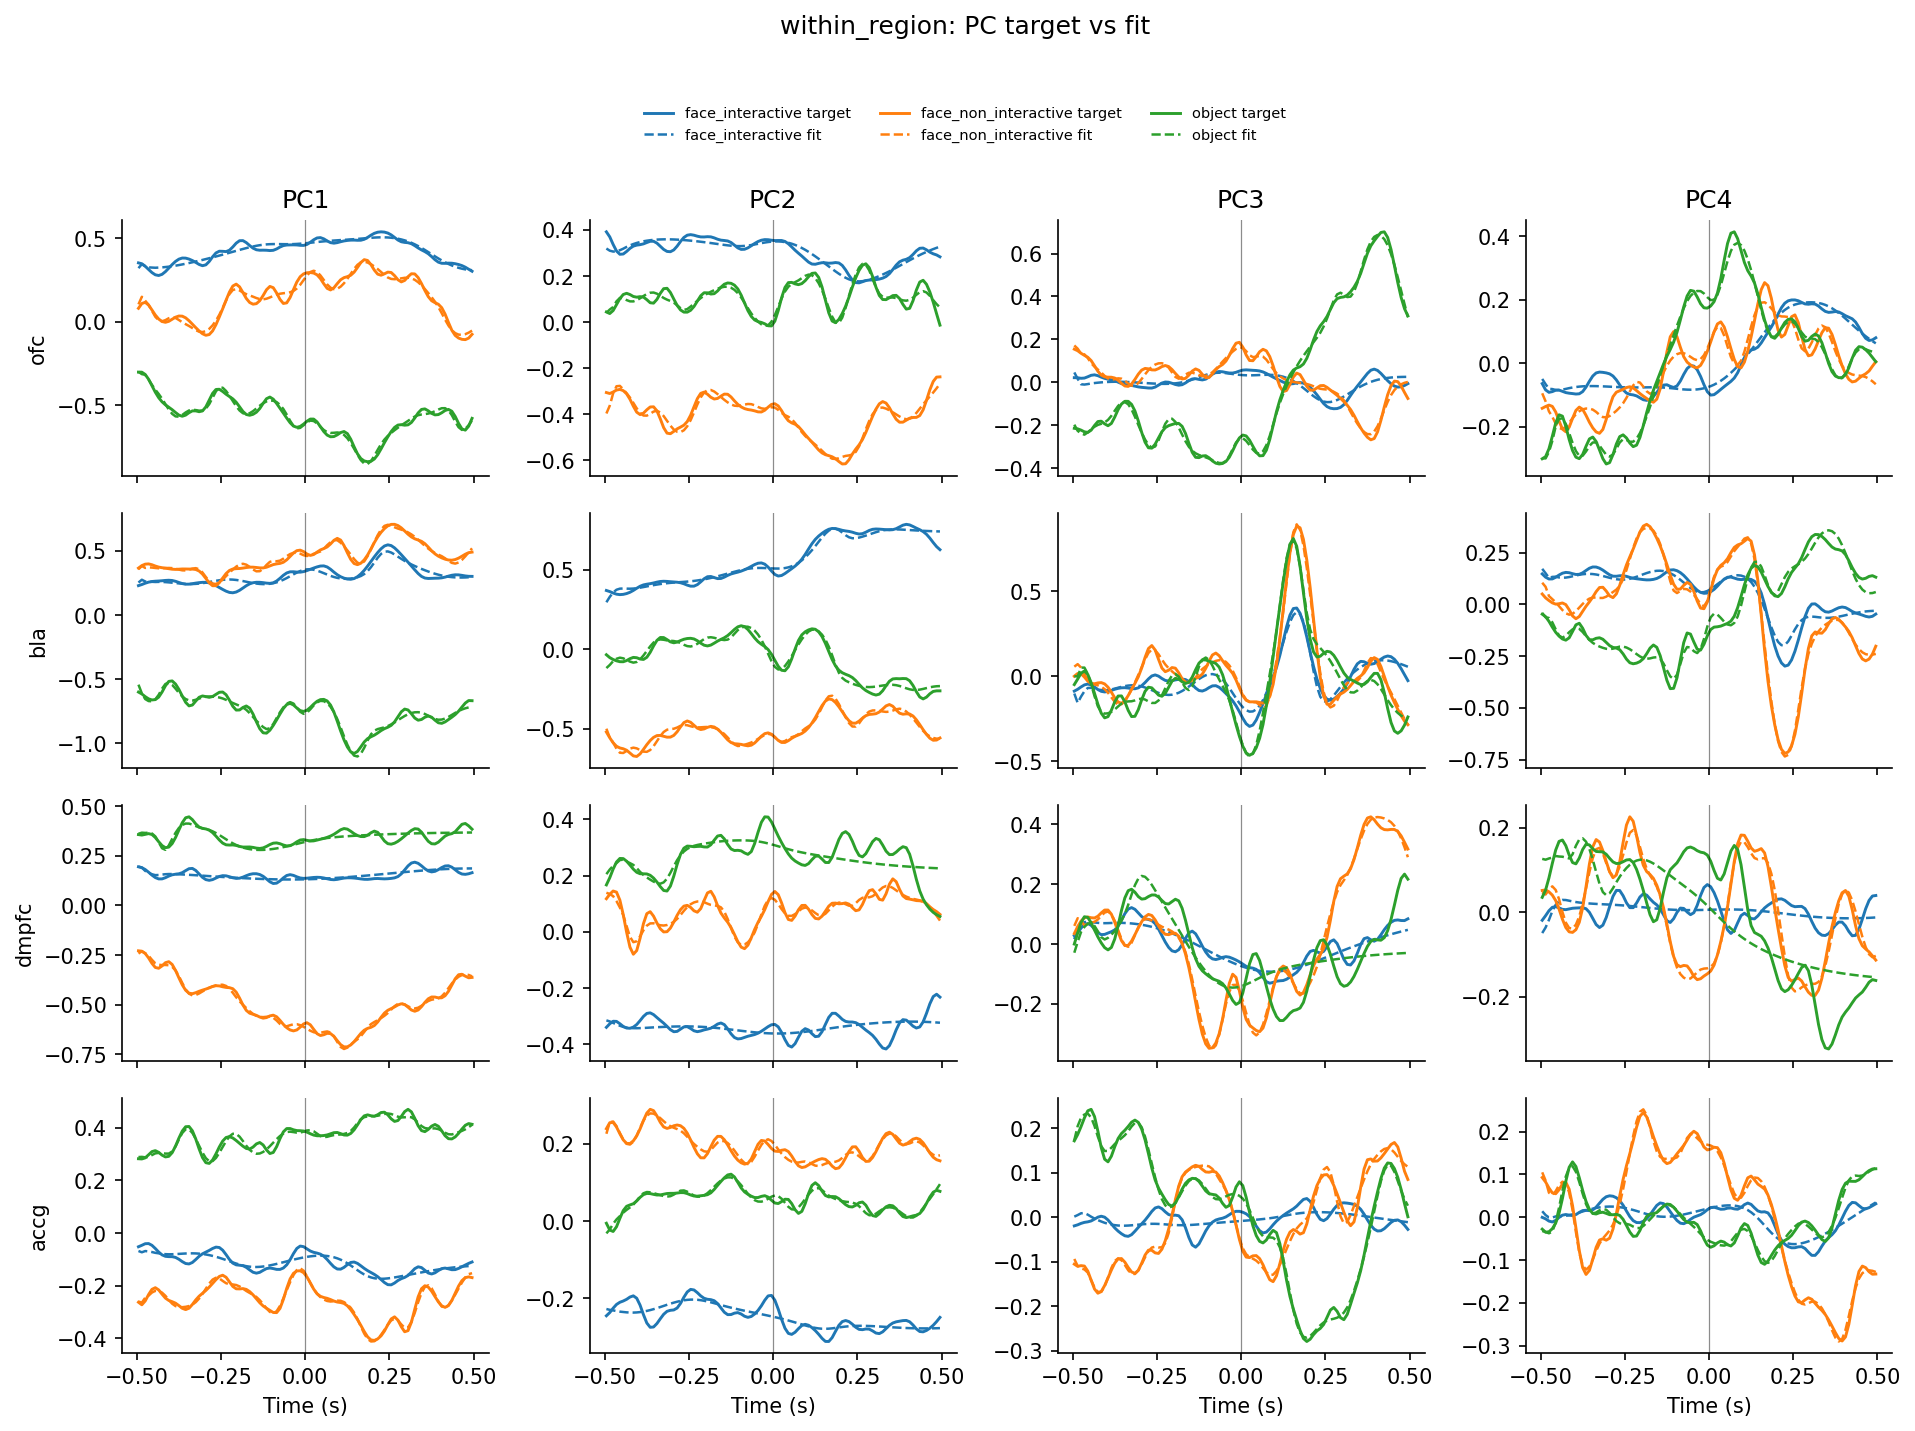

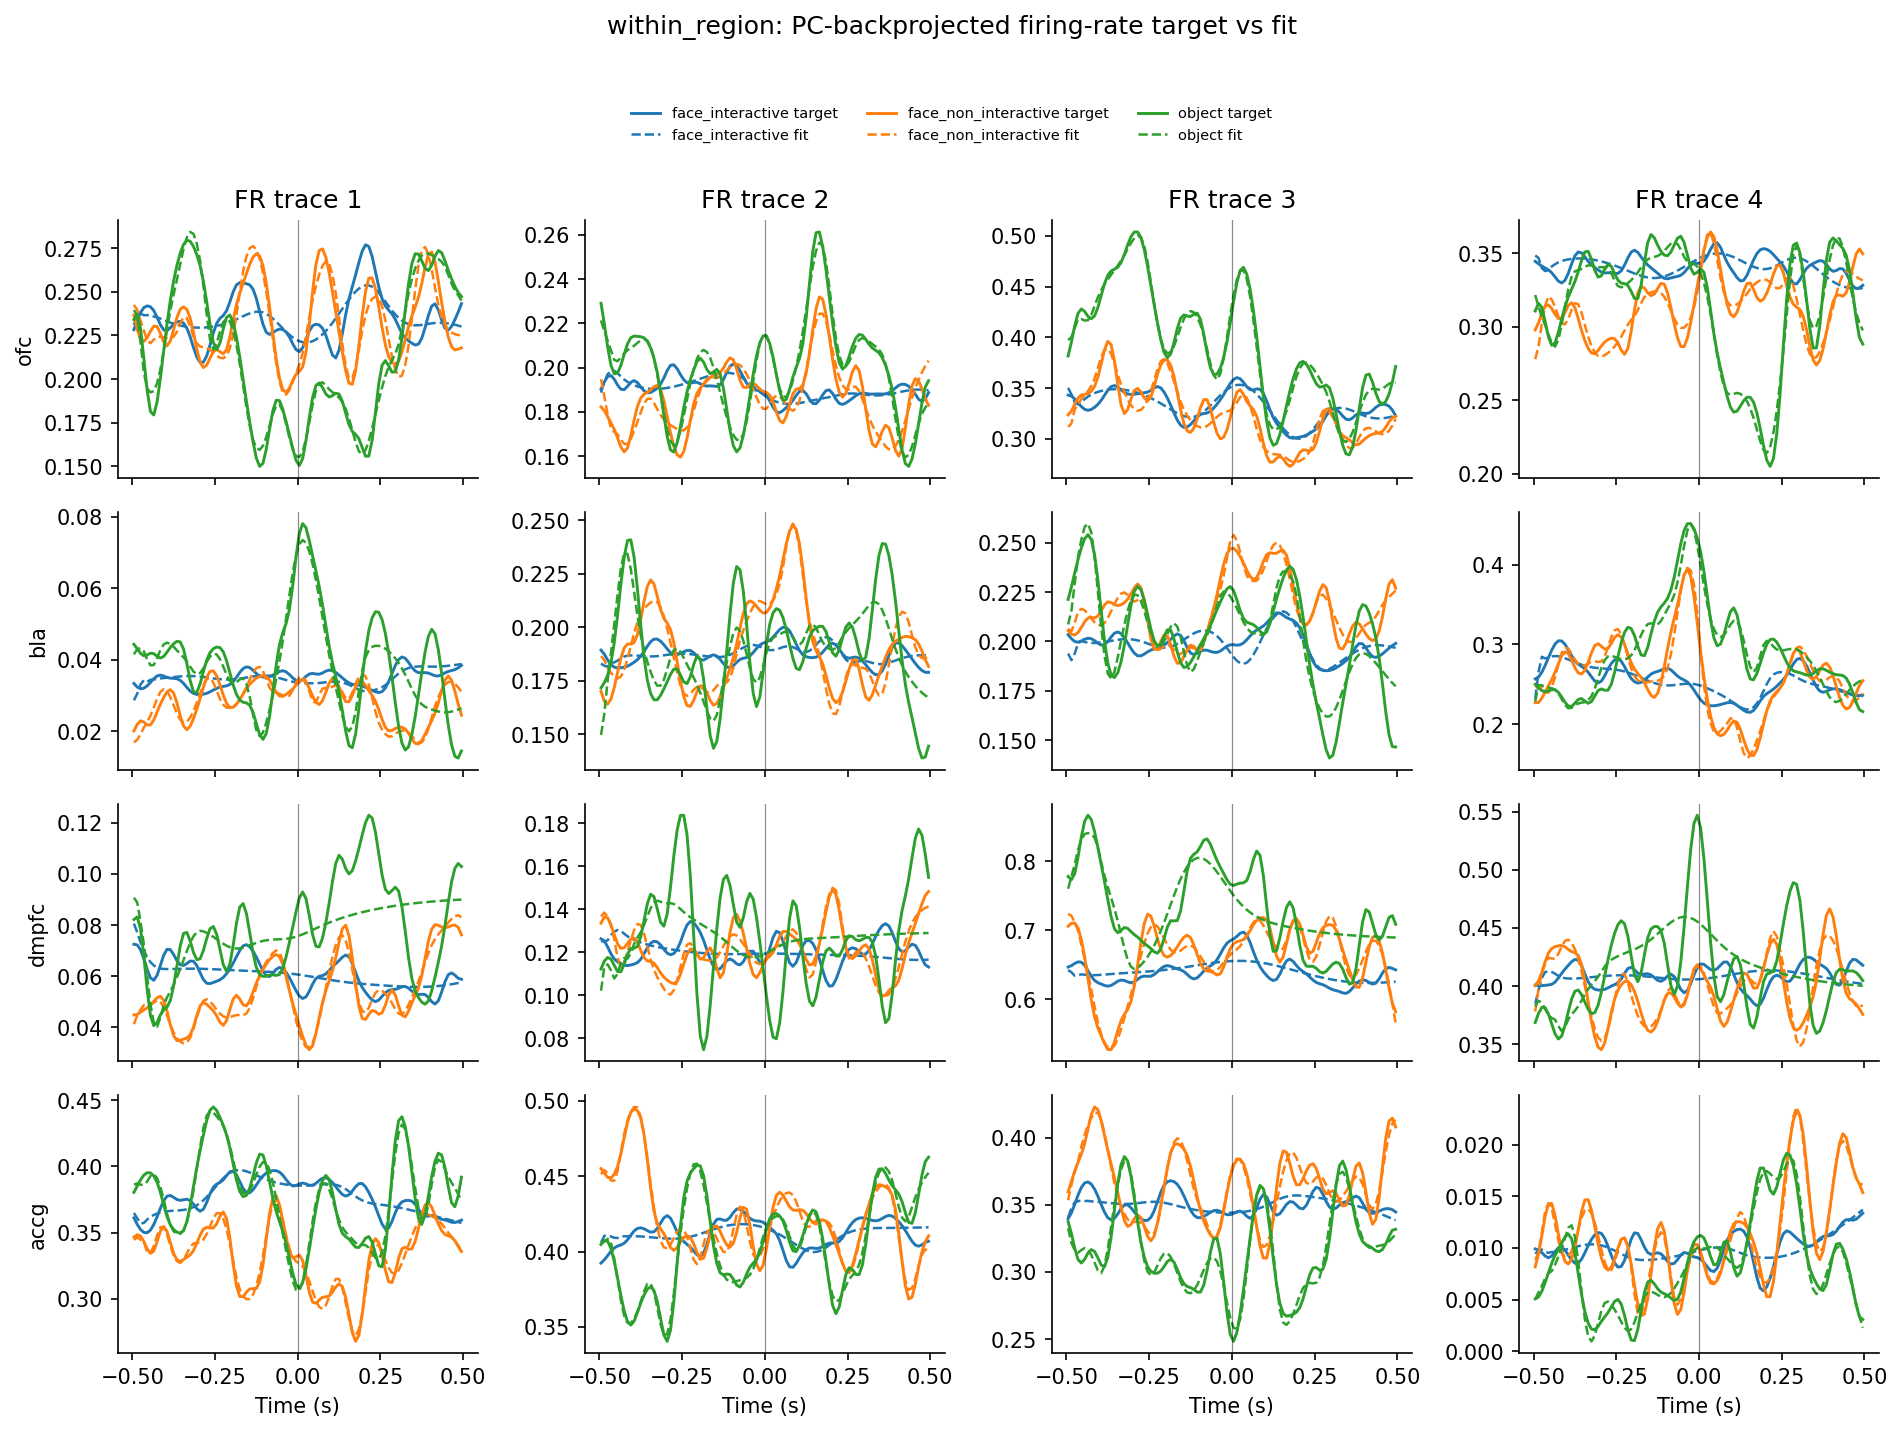

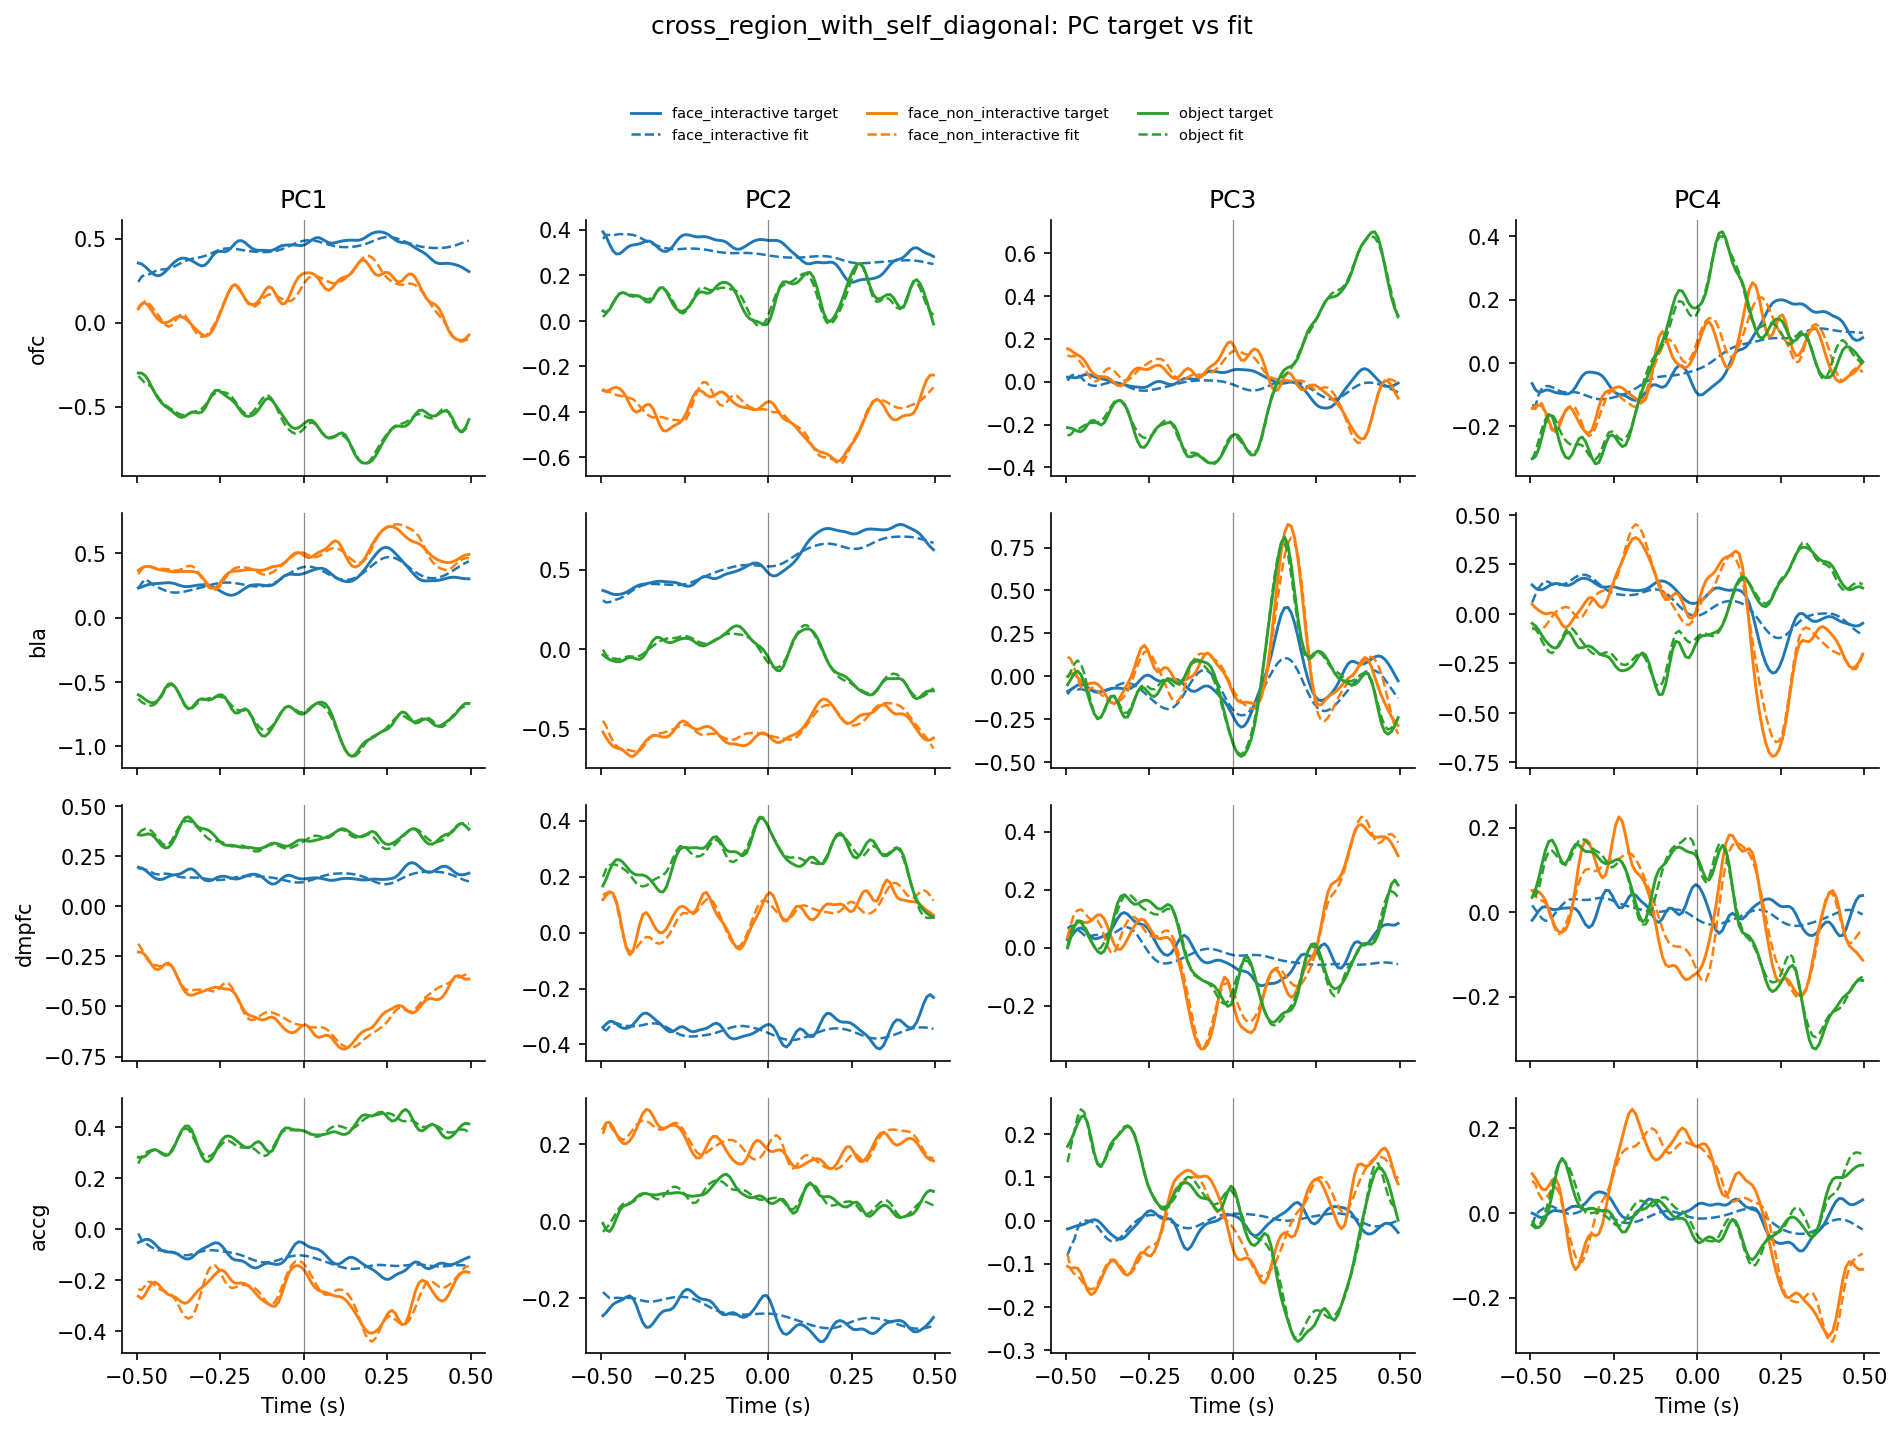

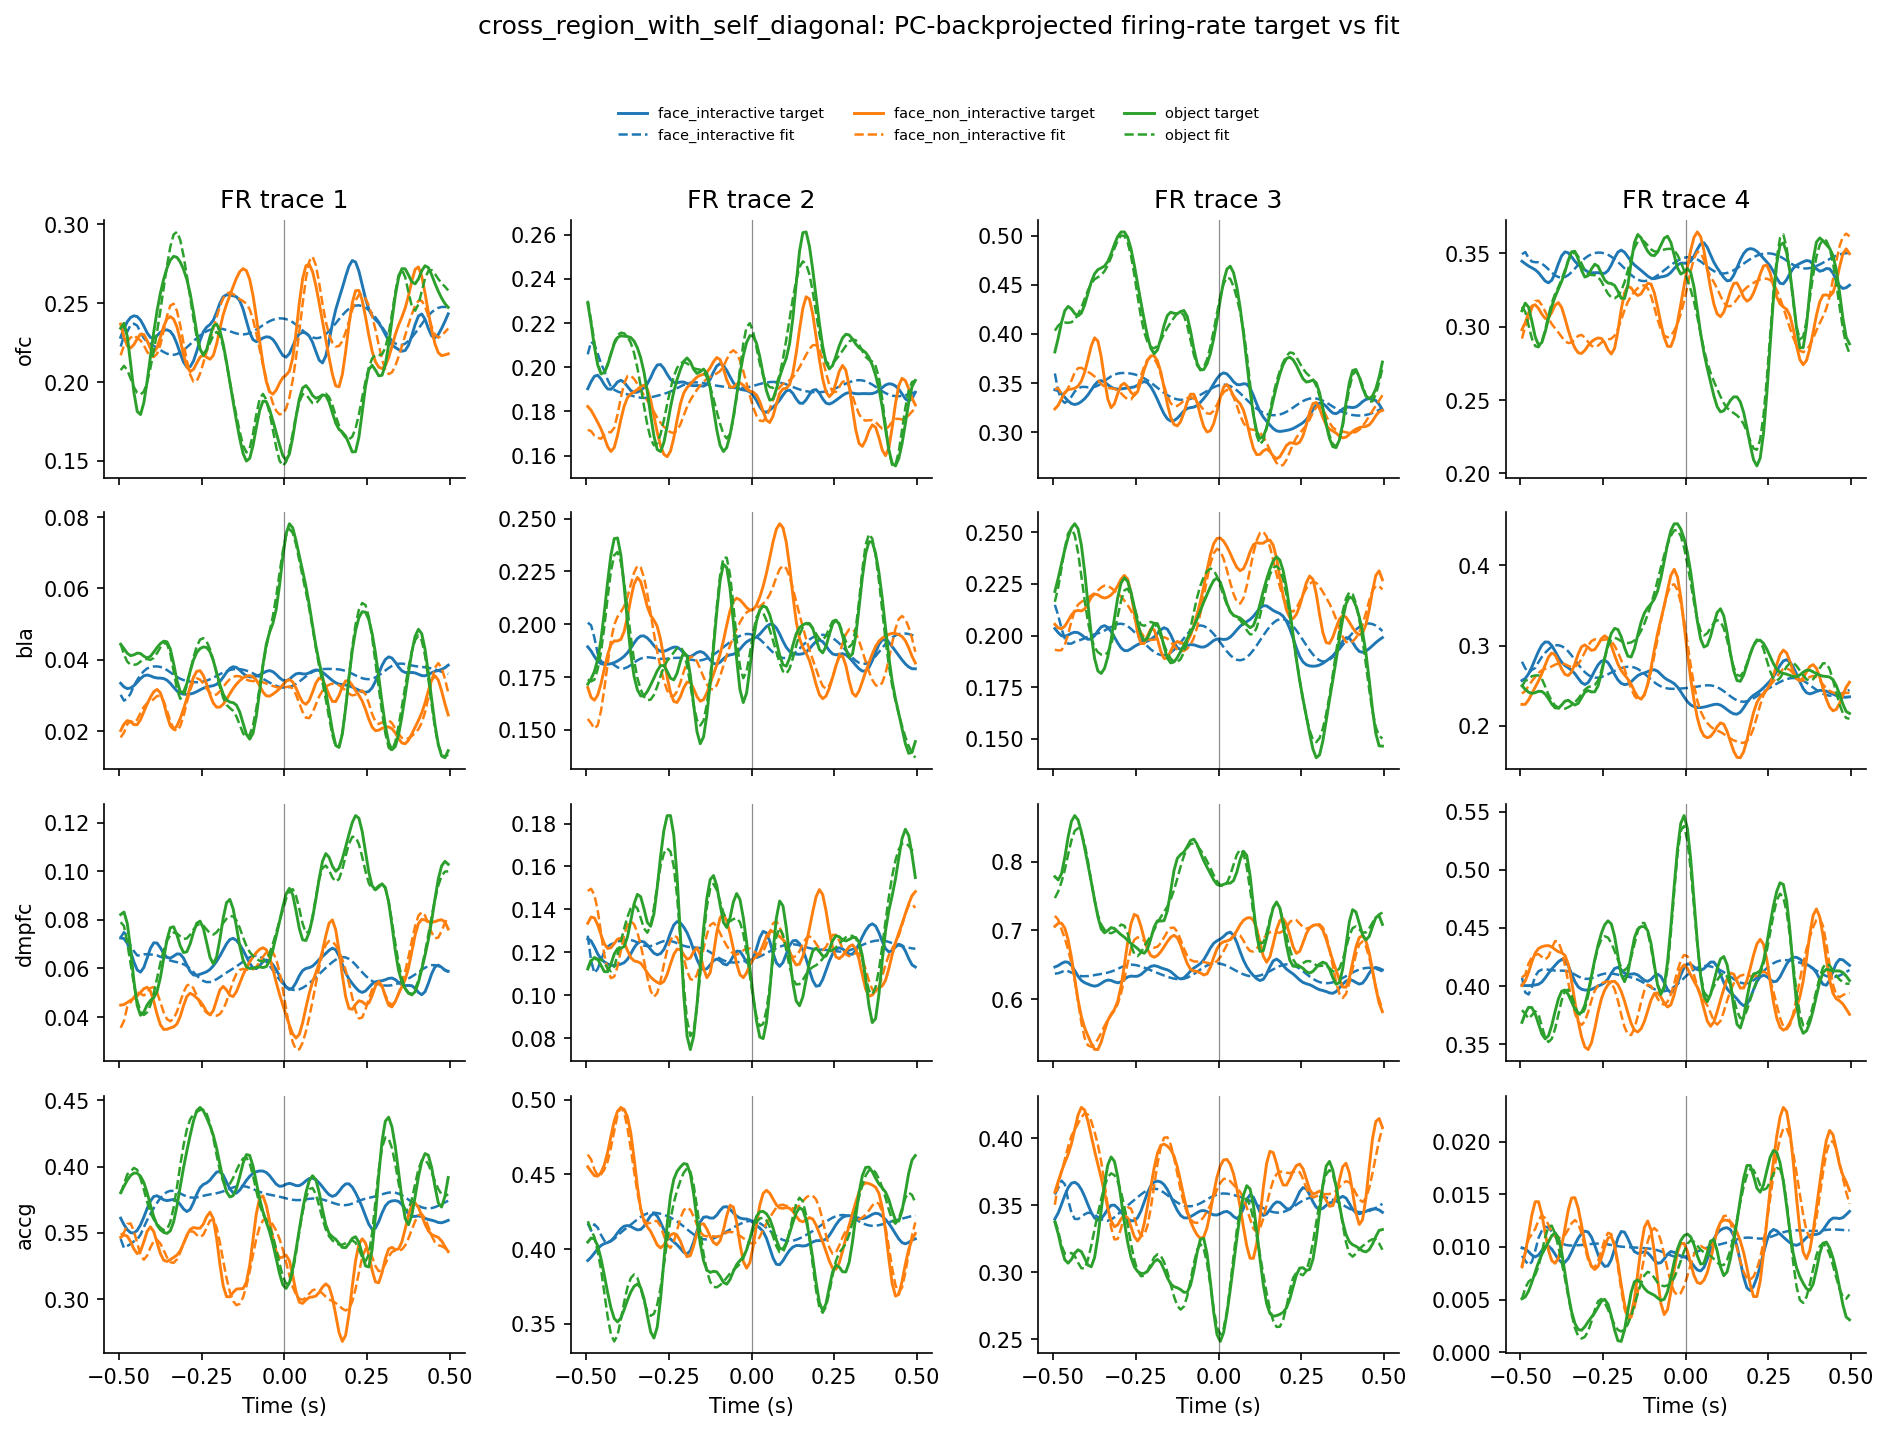

In [14]:
def _as_numpy_tensor(value):
    if hasattr(value, "detach"):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def plot_pc_reconstruction_overlay(replay, *, model_label, max_pcs=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    n_cols = min(int(max_pcs), min(np.asarray(replay["checkpoint"]["target_by_region"][regions[0]]).shape[-1], 4))
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=130,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(replay["checkpoint"]["target_by_region"][region], dtype=float)
        pred = _as_numpy_tensor(replay["output_by_region"][region]).astype(float)
        for pc_idx in range(n_cols):
            ax = axes[row, pc_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, pc_idx], color=color, linewidth=1.4, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, pc_idx], color=color, linewidth=1.2, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"PC{pc_idx + 1}")
            if pc_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC target vs fit", y=1.08)
    fig.tight_layout()
    return fig, axes


def plot_fr_reconstruction_overlay(replay, *, model_label, max_units=4):
    regions = tuple(replay["region_order"])
    conditions = tuple(replay["condition_order"])
    timeline = np.asarray(replay["checkpoint"]["timeline_s"], dtype=float)
    target_by_region = replay["checkpoint"].get("pc_reconstructed_raw_by_region")
    if target_by_region is None:
        target_by_region = replay["checkpoint"]["target_by_region"]
    predicted_by_region = backproject_replay_outputs_to_firing_rates(replay)
    n_cols = min(int(max_units), min(np.asarray(target_by_region[region]).shape[-1] for region in regions), 4)
    fig, axes = plt.subplots(
        len(regions),
        n_cols,
        figsize=(3.2 * n_cols, 2.2 * len(regions)),
        dpi=130,
        squeeze=False,
        sharex=True,
    )
    for row, region in enumerate(regions):
        target = np.asarray(target_by_region[region], dtype=float)
        pred = np.asarray(predicted_by_region[region], dtype=float)
        for unit_idx in range(n_cols):
            ax = axes[row, unit_idx]
            for cond_idx, condition in enumerate(conditions):
                color = plt.get_cmap("tab10")(cond_idx)
                ax.plot(timeline, target[cond_idx, :, unit_idx], color=color, linewidth=1.4, label=f"{condition} target")
                ax.plot(timeline, pred[cond_idx, :, unit_idx], color=color, linewidth=1.2, linestyle="--", label=f"{condition} fit")
            ax.axvline(0.0, color="black", linewidth=0.6, alpha=0.45)
            if row == 0:
                ax.set_title(f"FR trace {unit_idx + 1}")
            if unit_idx == 0:
                ax.set_ylabel(region)
            if row == len(regions) - 1:
                ax.set_xlabel("Time (s)")
            ax.spines[["top", "right"]].set_visible(False)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, frameon=False, fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{model_label}: PC-backprojected firing-rate target vs fit", y=1.08)
    fig.tight_layout()
    return fig, axes


for fit in fits:
    if fit["replay"] is None:
        continue
    fig, axes = plot_pc_reconstruction_overlay(fit["replay"], model_label=fit["label"], max_pcs=4)
    display_figure(fig)
    fig, axes = plot_fr_reconstruction_overlay(fit["replay"], model_label=fit["label"], max_units=4)
    display_figure(fig)
